<a href="https://colab.research.google.com/github/abeeraz379/Prediction-of-Product-sales/blob/main/prediction%20of%20product%20sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediction for product sales
 - ABeer Al-Zebda | Data Scientist


# Project Overview

#Load and inspect data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
path='/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/01-Fundamentals/Week02/Data/sales_predictions_2023.csv'
df=pd.read_csv(path)
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


#Clean Data

-  number of column :12
- number of rows :8522

 # Types of column
 Item_Identifier  | object

 Item_Weight      | float64

 Item_Fat_Content |  object

 Item_Visibility  | float64

 Item_Type        | object

 Item_MRP         | float64

 Outlet_Identifier|   object

 Outlet_Establishment_Year | int64

 Outlet_Size      | object

 Outlet_Location_Type      | object

 Outlet_Type    | object

 Item_Outlet_Sales |float64


In [9]:
df.duplicated(keep=False).sum()

np.int64(0)

# There is no duplicated

In [10]:
df.isna().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


# There are missing values in Item_weight Column and Outlet_Size Column

In [11]:
df['Item_Weight'].fillna(-1,inplace=True)
df['Item_Weight'].isna().sum()

/tmp/ipython-input-378/2818487300.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item_Weight'].fillna(-1,inplace=True)


np.int64(0)

In [12]:
df['Outlet_Size']=df['Outlet_Size'].fillna('missing')
df['Outlet_Size'].isna().sum()


np.int64(0)

In [13]:
df.isna().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


<Axes: >

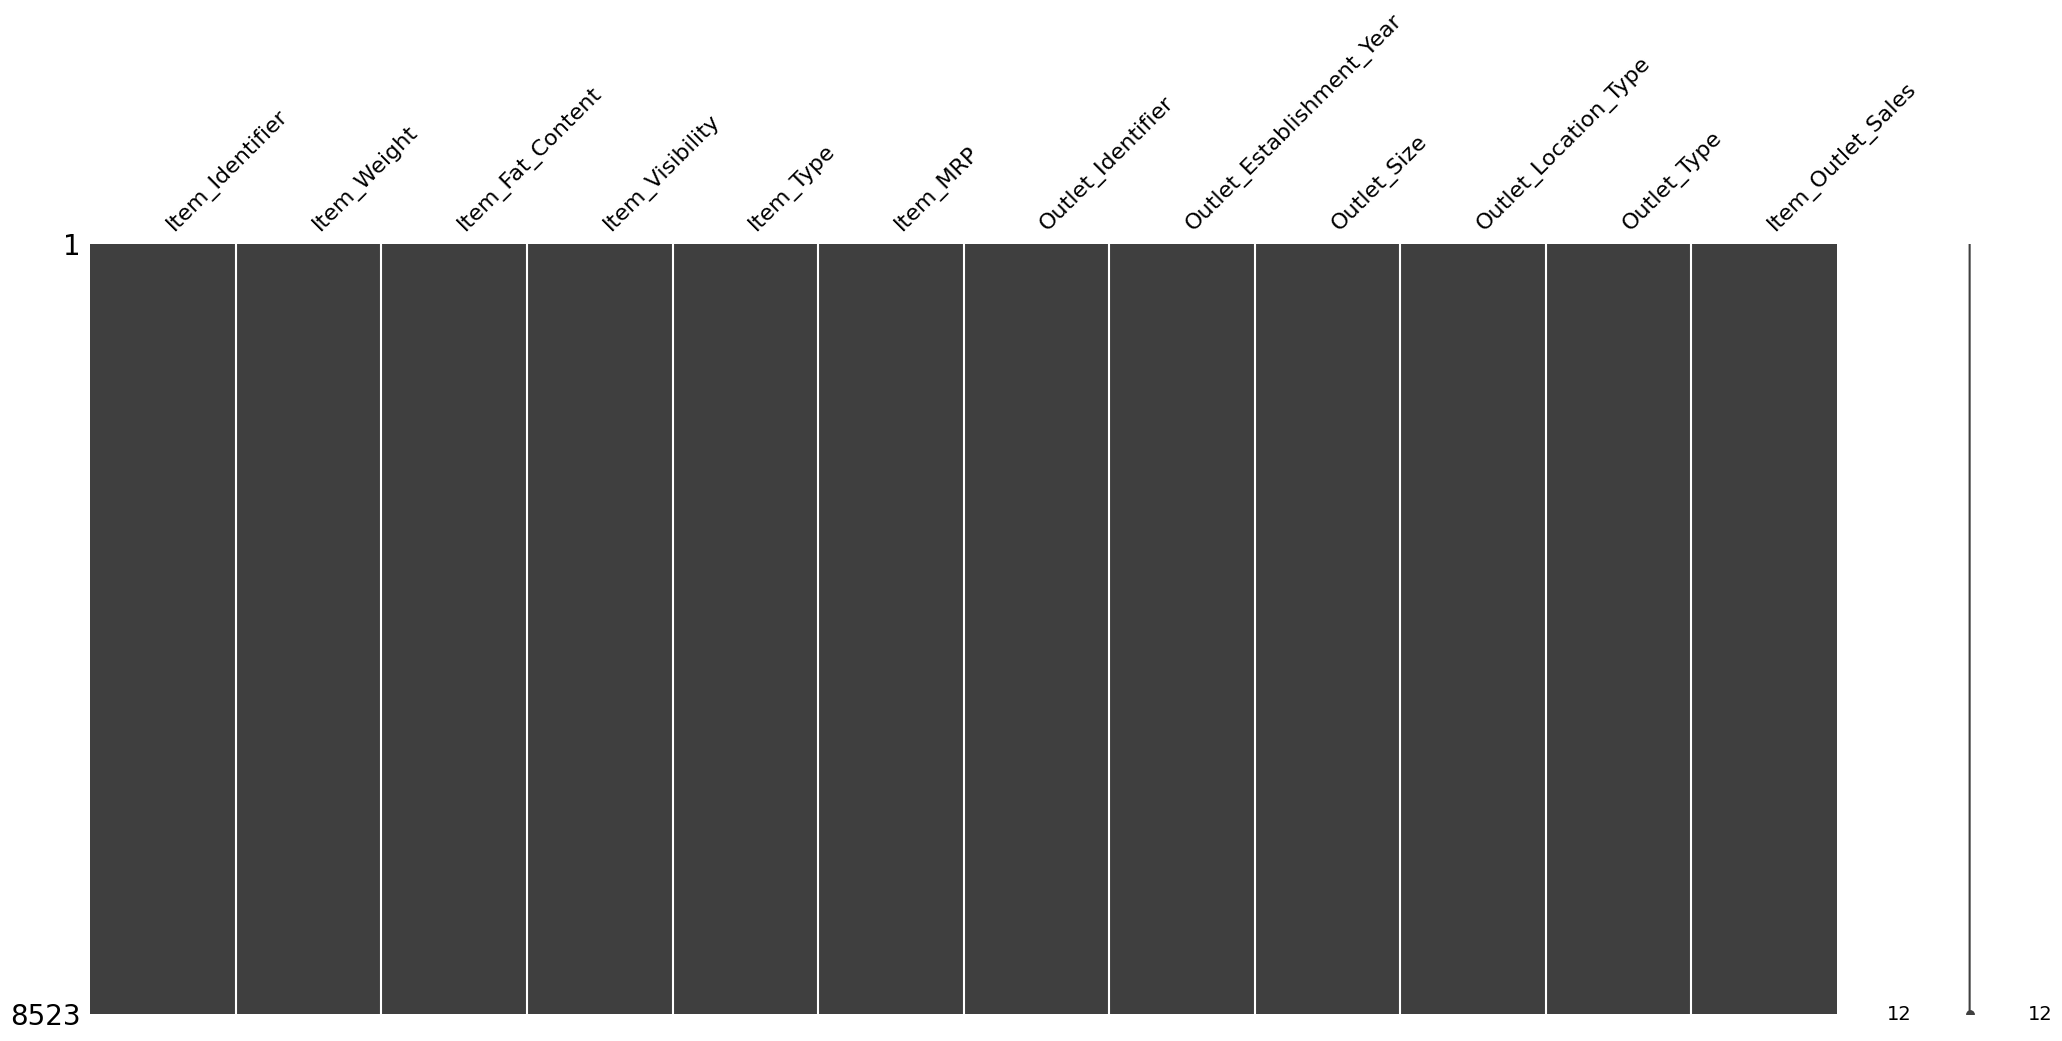

In [14]:
import missingno as msno
msno.matrix(df)

# Now There is no Missing Values

In [15]:
for col in df.columns:
  print( df[col].value_counts())
  print('\n')

Item_Identifier
FDW13    10
FDG33    10
FDX31     9
FDT07     9
NCY18     9
         ..
FDO33     1
FDK57     1
FDT35     1
FDN52     1
FDE52     1
Name: count, Length: 1559, dtype: int64


Item_Weight
-1.000     1463
 12.150      86
 17.600      82
 13.650      77
 11.800      76
           ... 
 5.210        2
 9.420        1
 7.685        1
 5.400        1
 6.520        1
Name: count, Length: 416, dtype: int64


Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64


Item_Visibility
0.000000    526
0.076975      3
0.061271      2
0.046825      2
0.112399      2
           ... 
0.054142      1
0.018920      1
0.044974      1
0.103611      1
0.083060      1
Name: count, Length: 7880, dtype: int64


Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
He

# I Find an inconsistent in Item_Fat_Content Column

In [16]:
df['Item_Fat_Content'].replace({'LF':'Low Fat','low fat':'Low Fat','reg':'Regular'},inplace=True)

/tmp/ipython-input-378/3737787646.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item_Fat_Content'].replace({'LF':'Low Fat','low fat':'Low Fat','reg':'Regular'},inplace=True)


In [17]:
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


# Now the data is consistent

In [18]:
df['Outlet_Establishment_Year'].describe()

,Outlet_Establishment_Year
count,8523.000000
mean,1997.831867
std,8.371760
min,1985.000000
25%,1987.000000
50%,1999.000000
75%,2004.000000
max,2009.000000


#Exploratory Data Analysis

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Histogram Plot

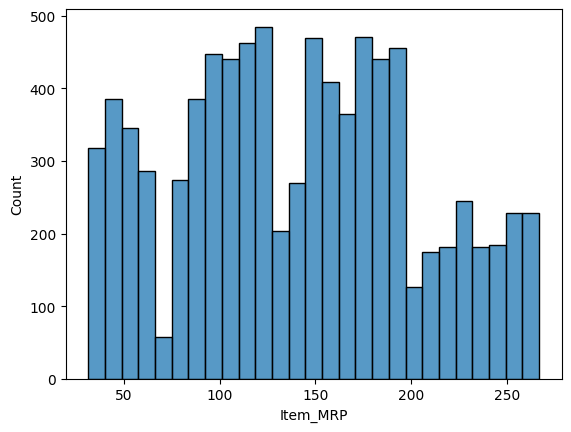

In [25]:
ax =sns.histplot(data=df, x='Item_MRP')

## Box Plot

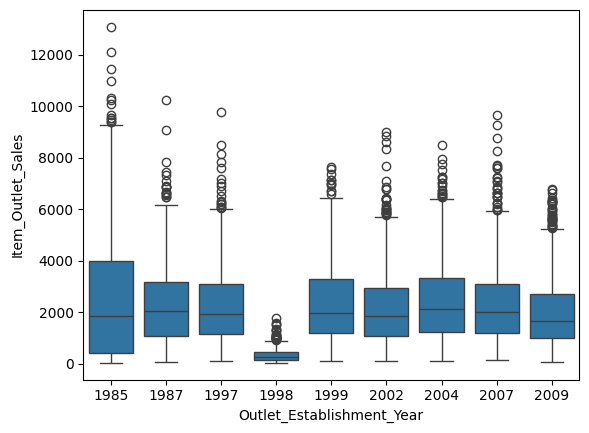

In [22]:
ax=sns.boxplot(data=df, y='Item_Outlet_Sales', x='Outlet_Establishment_Year')

## Count Plot

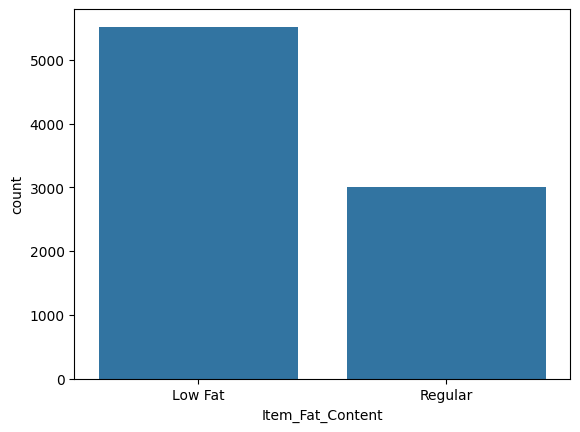

In [21]:
ax=sns.countplot(data=df , x='Item_Fat_Content')

## Heat Map Plot

<Axes: >

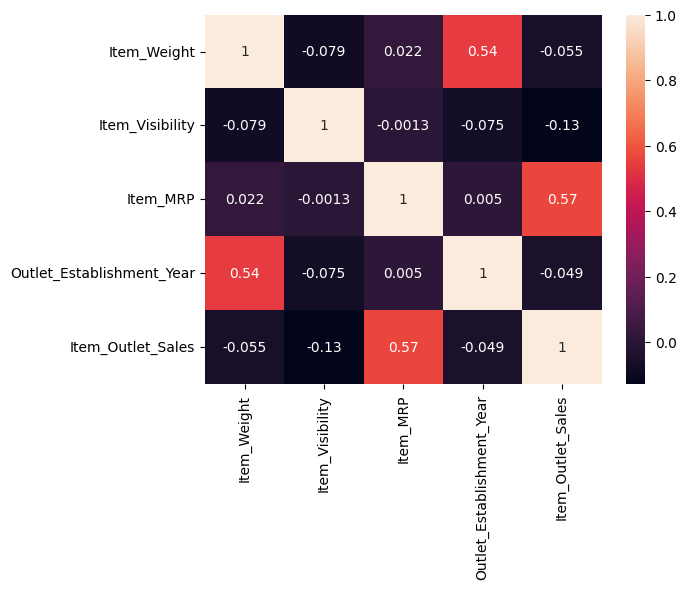

In [23]:
crr=df.corr(numeric_only=True)
sns.heatmap(crr,annot=True)

#Future Inspection